In [1]:
# ---- Setup: imports and physical constants ----
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'text.usetex': False, 'font.family': 'serif',
})

figdir = Path('figures')
figdir.mkdir(exist_ok=True)

# Physical constants
rho_i = 917.0       # ice density, kg/m^3
g = 9.81             # gravitational acceleration, m/s^2
sec_per_yr = 365.25 * 24 * 3600  # seconds per year
A = 2.4e-24          # Glen's law rate factor, Pa^{-n} s^{-1}
n = 3                # Glen's law exponent
rho_w = 1028.0       # ocean water density, kg/m^3

print('Setup complete.')

Setup complete.


## Figure 1: Effective Viscosity vs Strain Rate

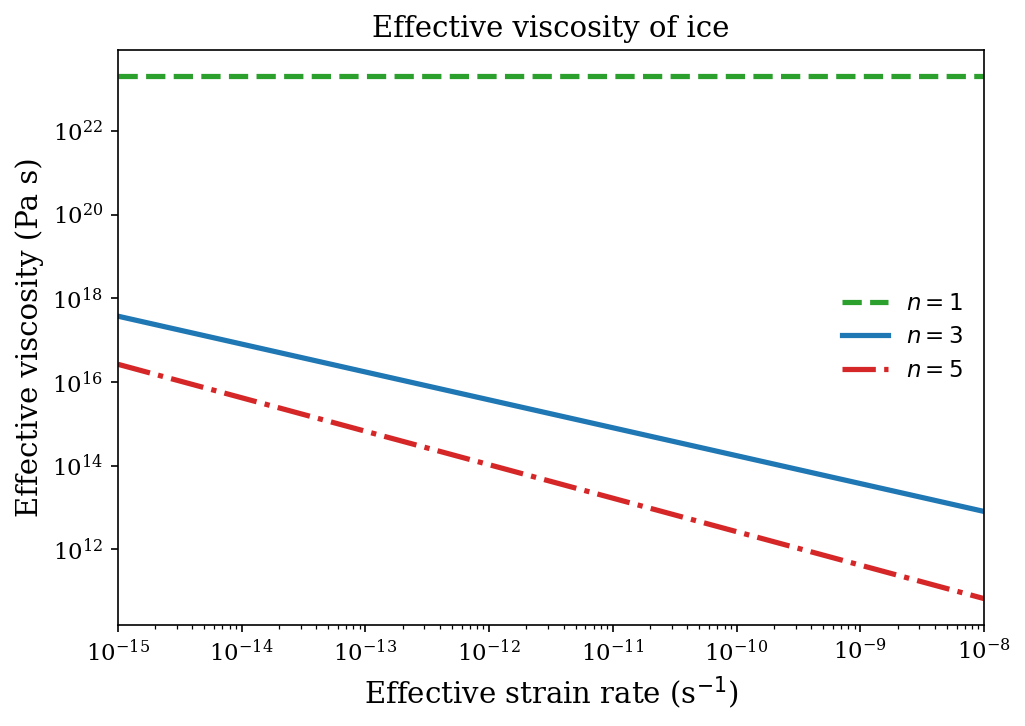

In [8]:
# ---- Fig1: effective viscosity vs strain rate ----
fig, ax = plt.subplots(figsize=(7, 5))

eps_e = np.logspace(-15, -8, 500)  # effective strain rate, s^{-1}

for n_val, color, ls in zip([1, 3, 5], ['#2ca02c', '#1f77b4', '#d62728'], ['--', '-', '-.']):
    eta = 0.5 * A**(-1.0/n_val) * eps_e**((1.0 - n_val)/n_val)
    ax.loglog(eps_e, eta, color=color, ls=ls, lw=2.5, label=f'$n = {n_val}$')

ax.set_xlabel(r'Effective strain rate (s$^{-1}$)')
ax.set_ylabel(r'Effective viscosity (Pa s)')
ax.legend(loc='center right', frameon=False)
ax.set_title('Effective viscosity of ice')
ax.set_xlim(1e-15, 1e-8)

fig.tight_layout()
fig.savefig(figdir / 'fig01_effective_viscosity.pdf')
fig.savefig(figdir / 'fig01_effective_viscosity.png')
plt.show()

## Figure 2: Weertman Ice Shelf Spreading Rate

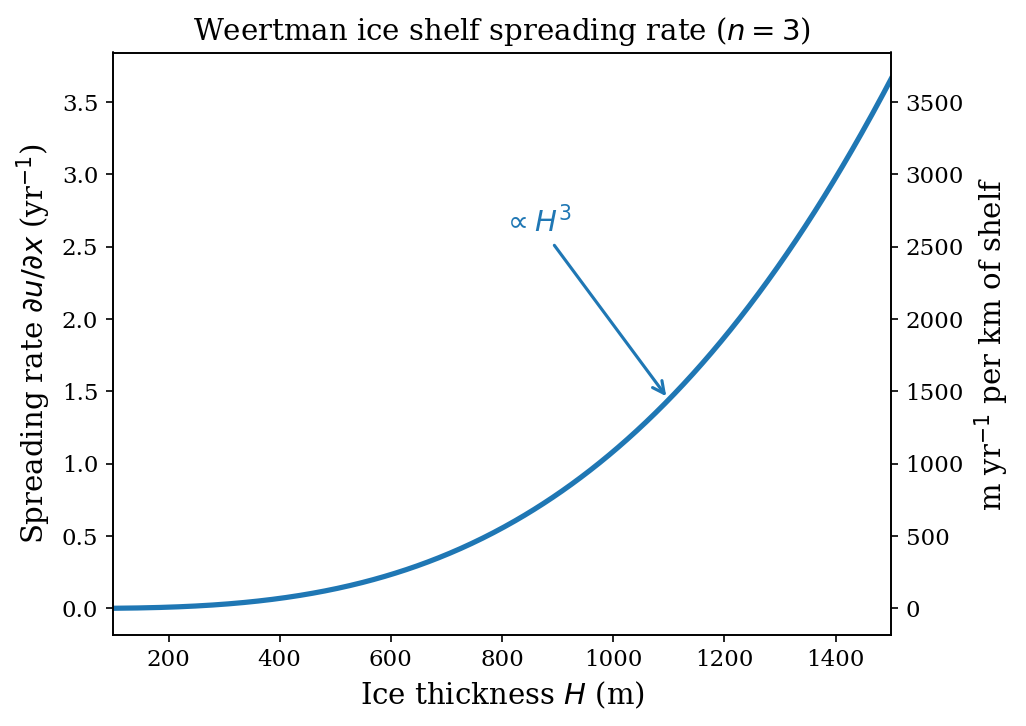

In [3]:
# ---- Fig2: Weertman ice shelf spreading rate ----
fig, ax1 = plt.subplots(figsize=(7, 5))

H = np.linspace(100, 1500, 500)  # ice thickness, m
n_val = 3

# Weertman spreading rate: du/dx = A * (rho_i * g * H * (1 - rho_i/rho_w) / 4)^n
dudx = A * (rho_i * g * H * (1.0 - rho_i / rho_w) / 4.0)**n_val  # s^{-1}
dudx_yr = dudx * sec_per_yr  # yr^{-1}

ax1.plot(H, dudx_yr, '-', color='#1f77b4', lw=2.5)
ax1.set_xlabel('Ice thickness $H$ (m)')
ax1.set_ylabel(r'Spreading rate $\partial u / \partial x$ (yr$^{-1}$)')
ax1.set_title(f'Weertman ice shelf spreading rate ($n = {n_val}$)')
ax1.set_xlim(100, 1500)

# Secondary y-axis: m/yr per km of shelf
ax2 = ax1.twinx()
ax2.plot(H, dudx_yr * 1000, '-', color='#1f77b4', lw=0, alpha=0)  # invisible, just to set scale
ax2.set_ylabel(r'm yr$^{-1}$ per km of shelf')
ax2.set_ylim(np.array(ax1.get_ylim()) * 1000)

# Annotate the H^n sensitivity
ax1.annotate(f'$\\propto H^{n_val}$', xy=(1100, A * (rho_i * g * 1100 * (1 - rho_i/rho_w) / 4)**n_val * sec_per_yr),
             fontsize=14, ha='left', va='bottom', color='#1f77b4',
             xytext=(800, dudx_yr.max() * 0.7),
             arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.5))

fig.tight_layout()
fig.savefig(figdir / 'fig02_weertman_spreading.pdf')
fig.savefig(figdir / 'fig02_weertman_spreading.png')
plt.show()

## Figure 3: Ice Stream Lateral Velocity Profiles

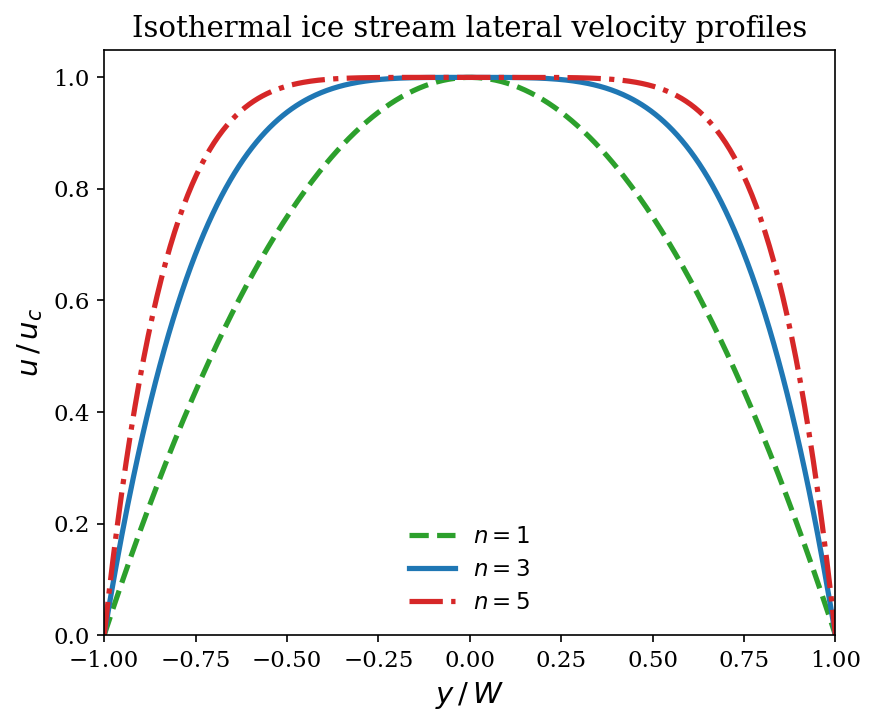

In [9]:
# ---- Fig3: ice stream lateral velocity profiles ----
fig, ax = plt.subplots(figsize=(6, 5))

y_W = np.linspace(-1, 1, 500)  # y / W

for n_val, color, ls in zip([1, 3, 5], ['#2ca02c', '#1f77b4', '#d62728'], ['--', '-', '-.']):
    u_uc = 1.0 - np.abs(y_W)**(n_val + 1)
    ax.plot(y_W, u_uc, color=color, ls=ls, lw=2.5, label=f'$n = {n_val}$')

ax.set_xlabel('$y \\, / \\, W$')
ax.set_ylabel('$u \\, / \\, u_c$')
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower center', frameon=False)
ax.set_title('Isothermal ice stream lateral velocity profiles')

fig.tight_layout()
fig.savefig(figdir / 'fig03_ice_stream_profiles.pdf')
fig.savefig(figdir / 'fig03_ice_stream_profiles.png')
plt.show()

## Figure 4: SIA vs Sliding-Modified SIA Thickness Profiles

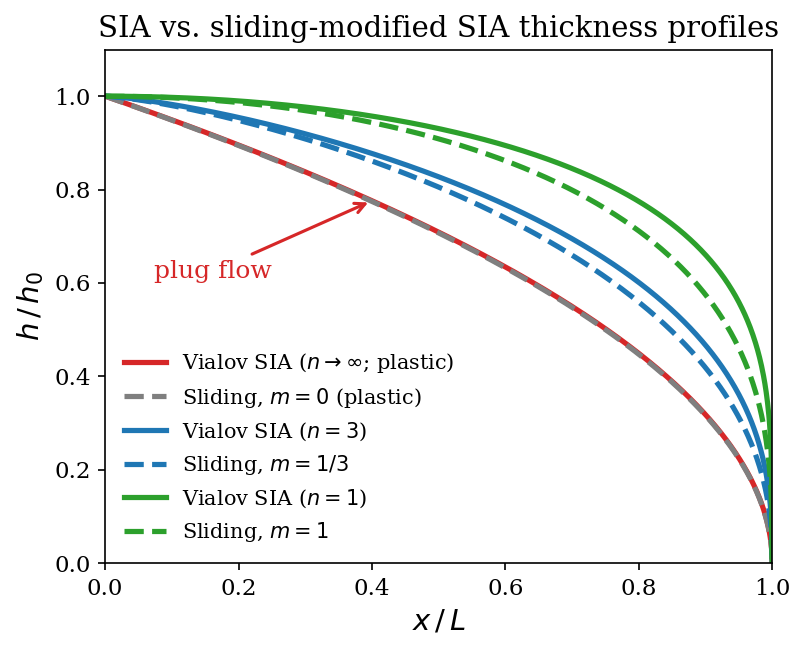

In [26]:
# ---- Fig4: SIA vs sliding-modified SIA thickness profiles ----
fig, ax = plt.subplots(figsize=(7, 4.5))

x_norm = np.linspace(0, 1, 1000)

# Vialov (SIA) 

n_val = 300
h_vialov = np.maximum(1 - x_norm**((n_val+1)/n_val), 0)**(n_val / (2*(n_val+1)))
ax.plot(x_norm, h_vialov, '-', color='#d62728', lw=2.5, label='Vialov SIA ($n\\to\\infty$; plastic)')

# Perfectly plastic (m -> 0): h/h0 = sqrt(1 - x/L)
h_plastic = np.sqrt(np.maximum(1 - x_norm, 0))
ax.plot(x_norm, h_plastic, '--', color='tab:grey', lw=2.5, label='Sliding, $m = 0$ (plastic)')

n_val = 3
h_vialov = np.maximum(1 - x_norm**((n_val+1)/n_val), 0)**(n_val / (2*(n_val+1)))
ax.plot(x_norm, h_vialov, '-', color='#1f77b4', lw=2.5, label='Vialov SIA ($n=3$)')

# Sliding-modified SIA with m=1/3
m_val = 1.0/n_val
h_m13 = np.maximum(1 - x_norm**(m_val + 1), 0)**(1.0 / (m_val + 2))
ax.plot(x_norm, h_m13, '--', color='#1f77b4', lw=2.5, label='Sliding, $m = 1/3$')

# Sliding-modified SIA with m=1
n_val = 1
h_vialov = np.maximum(1 - x_norm**((n_val+1)/n_val), 0)**(n_val / (2*(n_val+1)))
ax.plot(x_norm, h_vialov, '-', color='#2ca02c', lw=2.5, label='Vialov SIA ($n=1$)')

m_val = 1.0
h_m1 = np.maximum(1 - x_norm**(m_val + 1), 0)**(1.0 / (m_val + 2))
ax.plot(x_norm, h_m1, '--', color='#2ca02c', lw=2.5, label='Sliding, $m = 1$')

# Annotate Vialov SIA (n -> inf) line as 'plug flow'
x_ann = 0.4
n_ann = 300
y_ann = np.maximum(1 - x_ann**((n_ann+1)/n_ann), 0)**(n_ann / (2*(n_ann+1)))
ax.annotate('plug flow', xy=(x_ann, y_ann),
            xytext=(x_ann - 0.15, 0.6),
            fontsize=12, ha='right', va='bottom', color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))

ax.set_xlabel('$x \\, / \\, L$')
ax.set_ylabel('$h \\, / \\, h_0$')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title('SIA vs. sliding-modified SIA thickness profiles')
ax.set_aspect(0.7)

fig.tight_layout()
fig.savefig(figdir / 'fig04_sia_vs_sliding_profiles.pdf')
fig.savefig(figdir / 'fig04_sia_vs_sliding_profiles.png')
plt.show()

## Figure 5: Centerline Velocity vs Ice Stream Width

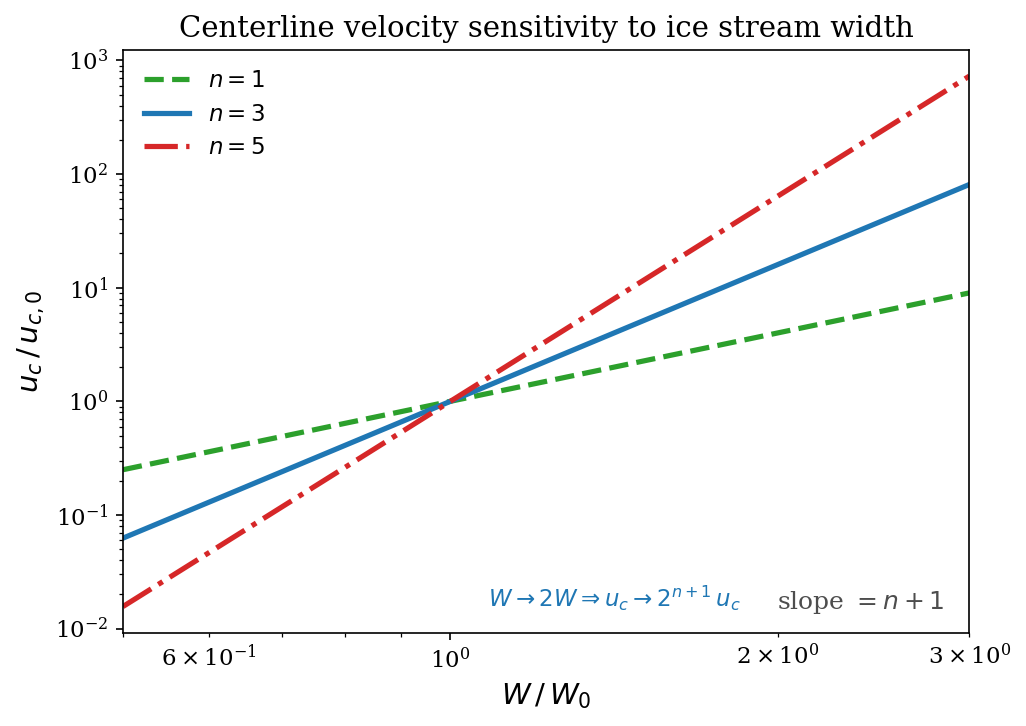

In [38]:
# ---- Fig5: centerline velocity vs ice stream width ----
fig, ax = plt.subplots(figsize=(7, 5))

W_W0 = np.linspace(0.5, 3, 500)  # W / W_0

for n_val, color, ls in zip([1, 3, 5], ['#2ca02c', '#1f77b4', '#d62728'], ['--', '-', '-.']):
    u_norm = W_W0**(n_val + 1)
    ax.loglog(W_W0, u_norm, color=color, ls=ls, lw=2.5, label=f'$n = {n_val}$')

# Annotate the scaling, centered between W/W0=1 and 2, just above x-axis
ax.text(np.sqrt(1.0 * 2.0), ax.get_ylim()[0] * 1.5,
        '$W \\to 2W \\Rightarrow u_c \\to 2^{n+1}\\,u_c$',
        fontsize=11, ha='center', va='bottom', color='#1f77b4')

# Slope note in lower right
ax.text(0.97, 0.03, 'slope $= n+1$', transform=ax.transAxes,
        fontsize=12, ha='right', va='bottom', color='0.3')

ax.set_xlabel('$W \\, / \\, W_0$')
ax.set_ylabel('$u_c \\, / \\, u_{c,0}$')
ax.legend(loc='upper left', frameon=False)
ax.set_title('Centerline velocity sensitivity to ice stream width')
ax.set_xlim(0.5, 3)

fig.tight_layout()
fig.savefig(figdir / 'fig05_width_sensitivity.pdf')
fig.savefig(figdir / 'fig05_width_sensitivity.png')
plt.show()

## Figure 6: Grounded vs Ice Shelf Thickness Profiles

/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_14582/2294034093.py:45: RuntimeWarning: All-NaN slice encountered
  ea_med = np.nanmedian(h_ea_resampled, axis=0)
/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


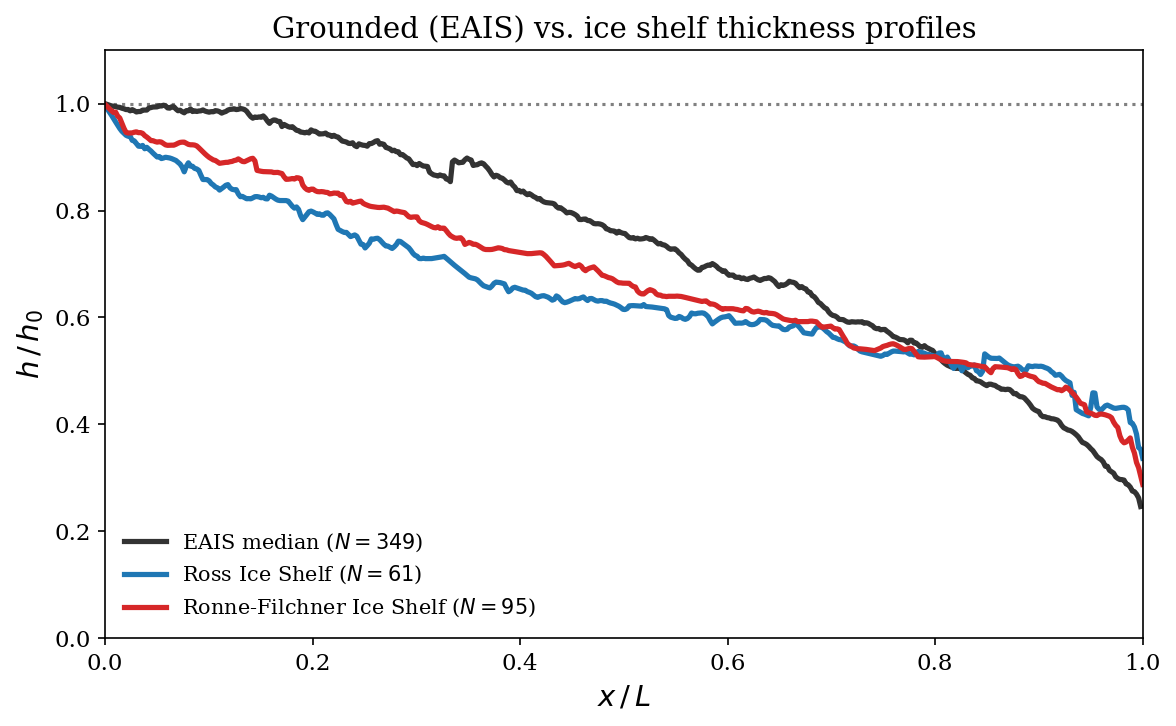

East Antarctica: 349 grounded profiles
Ross: 61 shelf profiles
Ronne-Filchner: 95 shelf profiles


In [52]:
# ---- Fig6: Grounded (East Antarctica) vs ice shelf thickness profiles ----
import h5py
from scipy.optimize import minimize_scalar

# --- Load East Antarctic grounded profiles (from dynamics_fundamentals_1) ---
ea_path = 'profiles/east_antarctica_profiles.h5'
import os
if not os.path.exists(ea_path):
    ea_path = '/Users/minchew/Dropbox/Teaching/glacier_dynamics/2026/lecture_notes/latex/dynamics_fundamentals_1/profiles/east_antarctica_profiles.h5'

with h5py.File(ea_path, 'r') as f:
    x_norm_ea = f['x_norm'][:]
    h_norm_ea = f['h_norm'][:]
    lengths_ea = f['profile_length_m'][:]
    gl_x_ea = f['grounding_line_x_norm'][:]

n_ea = h_norm_ea.shape[0]

# Fit Vialov L for each profile (same approach as dynamics_fundamentals_1)
def vialov_profile(x_norm, n):
    return np.maximum(1 - x_norm**((n+1)/n), 0)**(n/(2*(n+1)))

def fit_L(x_phys, h_obs, n):
    x_max = x_phys[-1]
    def cost(L):
        return np.mean((h_obs - vialov_profile(np.clip(x_phys/L, 0, 1), n))**2)
    res = minimize_scalar(cost, bounds=(x_max * 0.8, x_max * 3.0), method='bounded')
    return res.x

n_fit = 4
n_resamp = 500
xi_fit = np.linspace(0, 1, n_resamp)
h_ea_resampled = np.full((n_ea, n_resamp), np.nan)

for i in range(n_ea):
    gl_idx = min(np.searchsorted(x_norm_ea, gl_x_ea[i]), len(x_norm_ea) - 1)
    x_phys = x_norm_ea[:gl_idx+1] * lengths_ea[i]
    h_obs = h_norm_ea[i, :gl_idx+1]
    L_fit = fit_L(x_phys, h_obs, n_fit)
    x_fitted = x_phys / L_fit
    valid = x_fitted <= 1.0
    if valid.sum() > 10:
        h_ea_resampled[i, :] = np.interp(xi_fit, x_fitted[valid], h_obs[valid], right=np.nan)

ea_med = np.nanmedian(h_ea_resampled, axis=0)
ea_std = np.nanstd(h_ea_resampled, axis=0)
ea_enough = np.sum(np.isfinite(h_ea_resampled), axis=0) >= 10

# --- Load ice shelf profiles ---
shelf_path = 'profiles/ice_shelf_profiles.h5'
shelf_colors = {'Ross': '#1f77b4', 'Ronne-Filchner': '#d62728'}
shelf_data = {}

with h5py.File(shelf_path, 'r') as f:
    x_norm_shelf = f['x_norm'][:]
    for name in ['Ross', 'Ronne-Filchner']:
        grp = f[name]
        h_norm = grp['h_norm'][:]
        gl_xn = grp['grounding_line_x_norm'][:]
        n_prof = h_norm.shape[0]
        h_float_resampled = np.full((n_prof, n_resamp), np.nan)
        for i in range(n_prof):
            gl_idx = max(np.searchsorted(x_norm_shelf, gl_xn[i]), 1)
            x_float = x_norm_shelf[gl_idx:]
            h_float = h_norm[i, gl_idx:]
            if len(x_float) < 5:
                continue
            x_renorm = (x_float - x_float[0]) / (x_float[-1] - x_float[0])
            h_float_resampled[i, :] = np.interp(xi_fit, x_renorm, h_float)
        shelf_data[name] = h_float_resampled

# --- Figure: single panel ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(1,color='0.5',ls=':')

# East Antarctic grounded profiles
#ax.fill_between(xi_fit[ea_enough],
#                (ea_med - ea_std)[ea_enough], (ea_med + ea_std)[ea_enough],
#                color='0.75', alpha=0.4, label=r'EAIS $\pm\,1\sigma$')
ax.plot(xi_fit[ea_enough], ea_med[ea_enough], '-', color='0.2', lw=2.5,
        label=f'EAIS median ($N = {n_ea}$)')

# Ice shelf profiles
for name, color in shelf_colors.items():
    h_all = shelf_data[name]
    med = np.nanmedian(h_all, axis=0)
    std = np.nanstd(h_all, axis=0)
    n_valid = np.sum(np.isfinite(h_all), axis=0)
    enough = n_valid >= 3
    n_prof = np.sum(np.any(np.isfinite(h_all), axis=1))
    #ax.fill_between(xi_fit[enough],
    #                (med - std)[enough], (med + std)[enough],
    #                color=color, alpha=0.15)
    ax.plot(xi_fit[enough], med[enough], '-', color=color, lw=2.5,
            label=f'{name} Ice Shelf ($N = {n_prof}$)')

ax.set_xlabel(r'$x \, / \, L$')
ax.set_ylabel(r'$h \, / \, h_0$')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title('Grounded (EAIS) vs. ice shelf thickness profiles')

fig.tight_layout()
fig.savefig(figdir / 'fig06_grounded_vs_shelf_profiles.pdf')
fig.savefig(figdir / 'fig06_grounded_vs_shelf_profiles.png')
plt.show()

print(f'East Antarctica: {n_ea} grounded profiles')
for name, h_all in shelf_data.items():
    n_prof = np.sum(np.any(np.isfinite(h_all), axis=1))
    print(f'{name}: {n_prof} shelf profiles')